In [1]:
from pathlib import Path
import pandas as pd
from scipy.stats import skew, kurtosis
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from typing import Literal
from sklearn.preprocessing import MinMaxScaler,StandardScaler

data_path = Path("../data/processed/NVDA_outliers.csv")
df = pd.read_csv(data_path)
df

,date,adj close,close,high,low,open,volume,ticker,daily_rtn,excess_return,outlier_iqr,outlier_winsorize,outlier_z
0,2020-08-20,12.101113,12.141000,12.375000,11.878750,11.975000,921388000,NVDA,0.000206,-0.002953,False,-0.002953,False
1,2020-08-21,12.641834,12.683500,12.808750,12.195250,12.201750,999868000,NVDA,0.044684,0.041242,False,0.041242,False
2,2020-08-24,12.678459,12.720250,12.912500,12.507500,12.883750,490564000,NVDA,0.002897,-0.007147,False,-0.007147,False
3,2020-08-25,12.708115,12.750000,12.761250,12.573750,12.630750,289076000,NVDA,0.002339,-0.001257,False,-0.001257,False
4,2020-08-26,12.731039,12.773000,12.868500,12.677750,12.799250,321244000,NVDA,0.001804,-0.008392,False,-0.008392,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,2025-08-12,183.160004,183.160004,184.479996,179.460007,182.960007,145485700,NVDA,0.006042,-0.005303,False,-0.005303,False
1211,2025-08-13,181.589996,181.589996,183.970001,179.350006,182.619995,179871700,NVDA,-0.008572,-0.011802,False,-0.011802,False
1212,2025-08-14,182.020004,182.020004,183.020004,179.460007,179.750000,129554000,NVDA,0.002368,0.002065,False,0.002065,False
1213,2025-08-15,180.449997,180.449997,181.899994,178.039993,181.880005,156602200,NVDA,-0.008625,-0.005728,False,-0.005728,False


In [2]:
desc = df[['adj close','high','low','open',"volume","daily_rtn","excess_return"]].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc.reset_index()
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
adj close,1215.0,5.437052e+01,4.858406e+01,1.121416e+01,1.679741e+01,2.764427e+01,9.248318e+01,1.831600e+02,0.991004,-0.494504
high,1215.0,5.531870e+01,4.931226e+01,1.173500e+01,1.711050e+01,2.806500e+01,9.475900e+01,1.844800e+02,0.982592,-0.526746
low,1215.0,5.336303e+01,4.773521e+01,1.081300e+01,1.627350e+01,2.714500e+01,9.000350e+01,1.805900e+02,0.999638,-0.462509
open,1215.0,5.438502e+01,4.858433e+01,1.097100e+01,1.666900e+01,2.765100e+01,9.218000e+01,1.829600e+02,0.991506,-0.494047
volume,1215.0,4.050463e+08,1.764791e+08,9.788400e+07,2.646298e+08,3.889710e+08,5.129825e+08,1.463684e+09,0.881556,1.522192
daily_rtn,1215.0,1.989649e-03,2.831836e-02,-9.472604e-02,-1.526729e-02,2.969818e-03,2.009667e-02,8.237919e-02,-0.154666,0.208020
excess_return,1215.0,1.569425e-03,2.184984e-02,-5.859142e-02,-1.319068e-02,8.946888e-04,1.560899e-02,6.037013e-02,0.056042,-0.124969


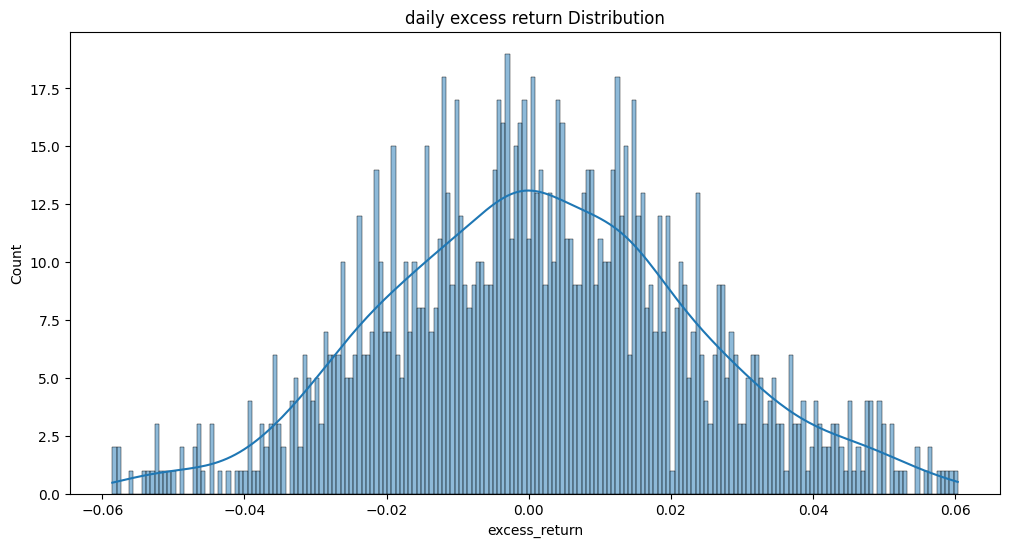

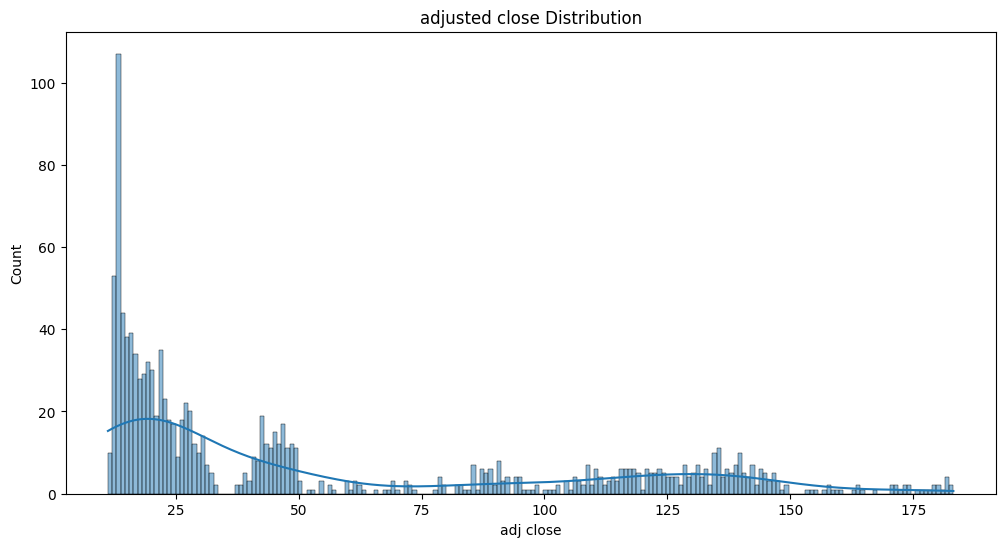

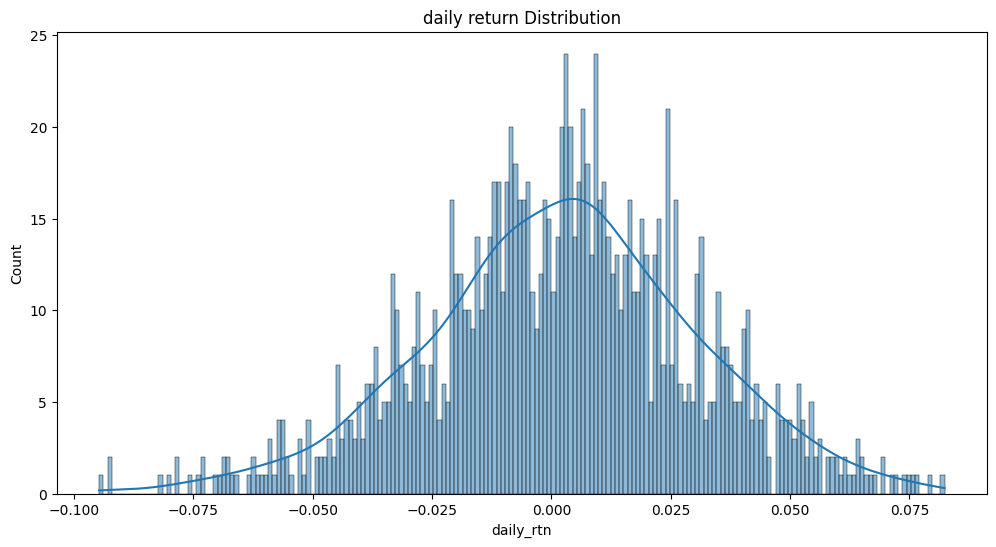

In [3]:
#histogram plot
plt.figure(figsize=(12,6))
sns.histplot(df['excess_return'], kde=True,bins = 200)
plt.title('daily excess return Distribution')


plt.figure(figsize=(12,6))
sns.histplot(df['adj close'], kde=True,bins = 200)
plt.title('adjusted close Distribution')


plt.figure(figsize=(12,6))
sns.histplot(df['daily_rtn'], kde=True,bins = 200)
plt.title('daily return Distribution')

plt.show()

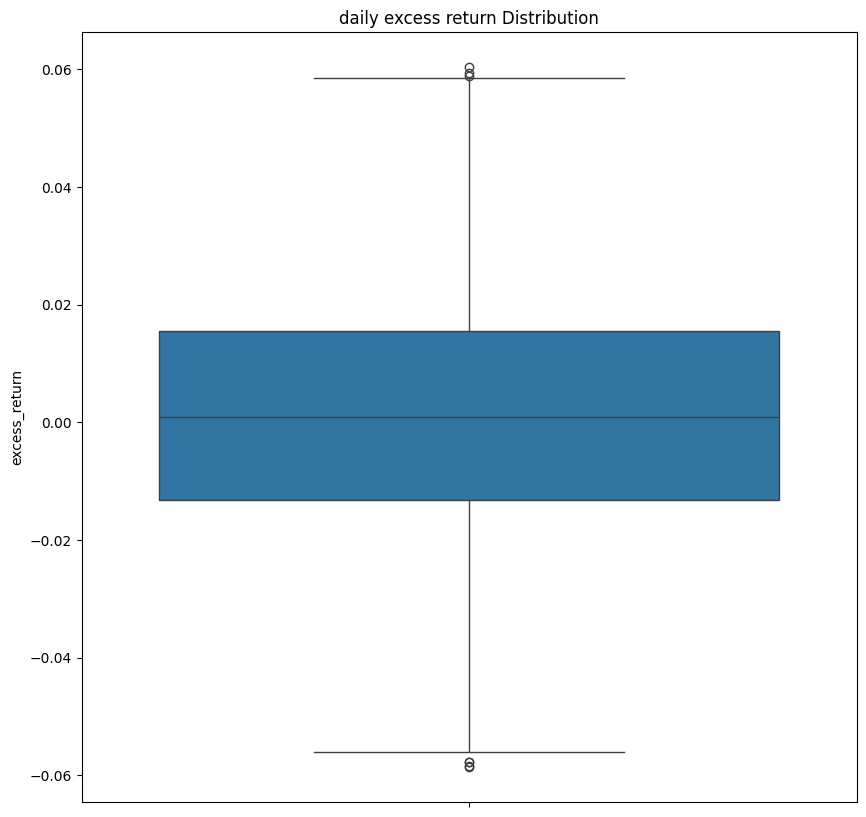

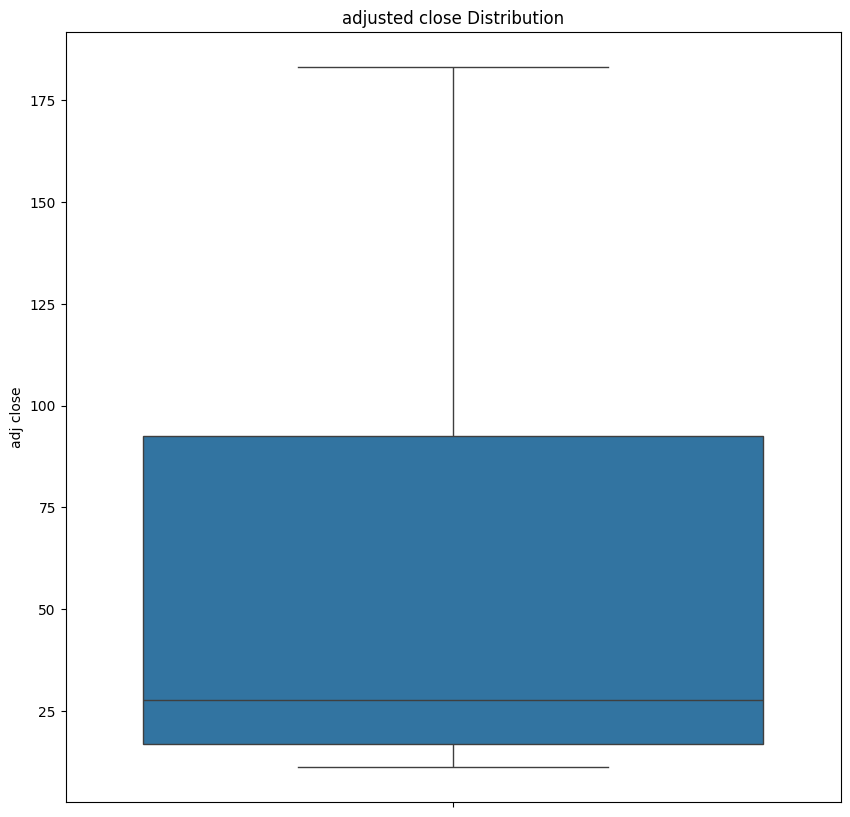

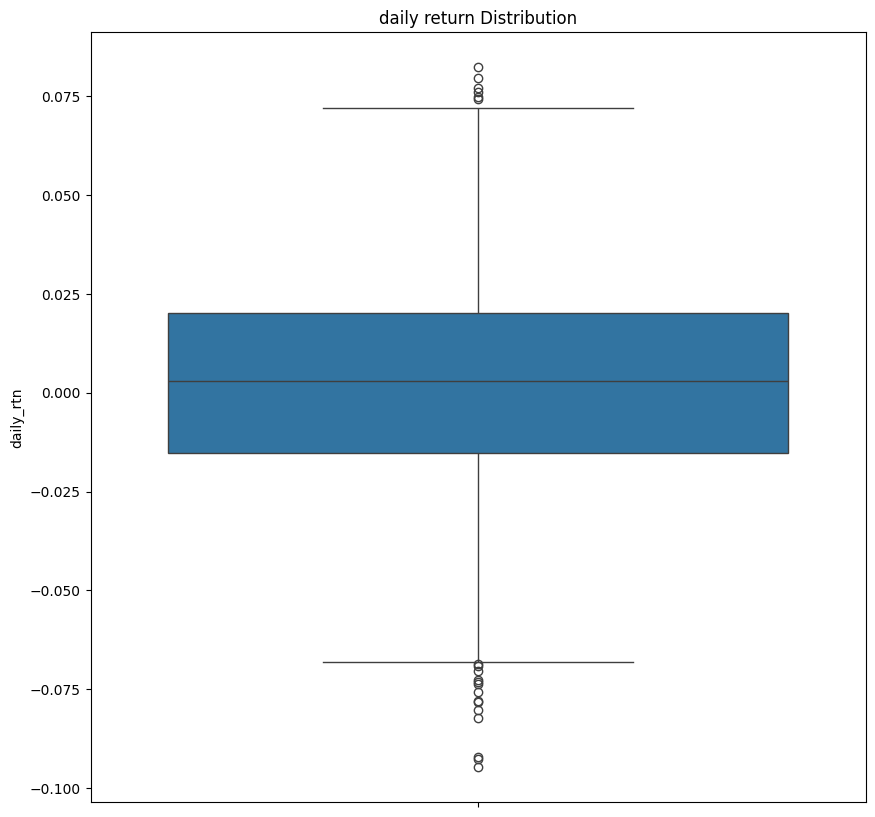

In [4]:
#boxplot
plt.figure(figsize=(10,10))
sns.boxplot(df['excess_return'])
plt.title('daily excess return Distribution')


plt.figure(figsize=(10,10))
sns.boxplot(df['adj close'])
plt.title('adjusted close Distribution')


plt.figure(figsize=(10,10))
sns.boxplot(df['daily_rtn'])
plt.title('daily return Distribution')

plt.show()

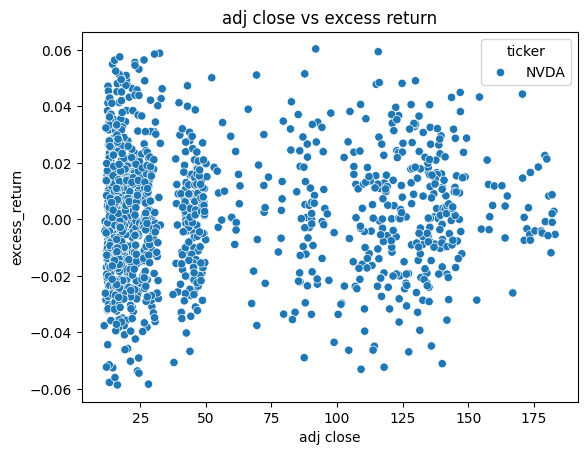

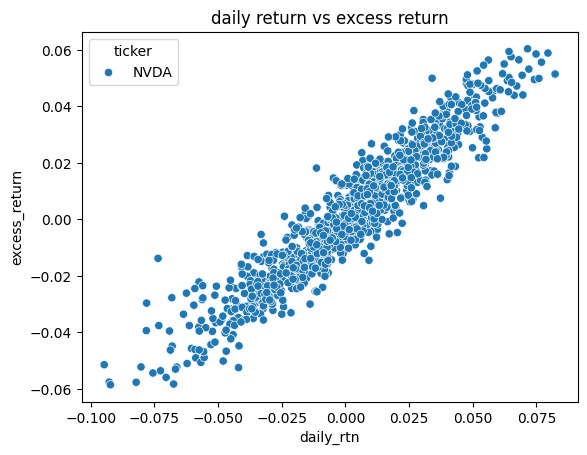

In [5]:
sns.scatterplot(data=df, x='adj close', y='excess_return',hue="ticker")
plt.title('adj close vs excess return')
plt.show()

sns.scatterplot(data=df, x='daily_rtn', y='excess_return',hue="ticker")
plt.title('daily return vs excess return')
plt.show()

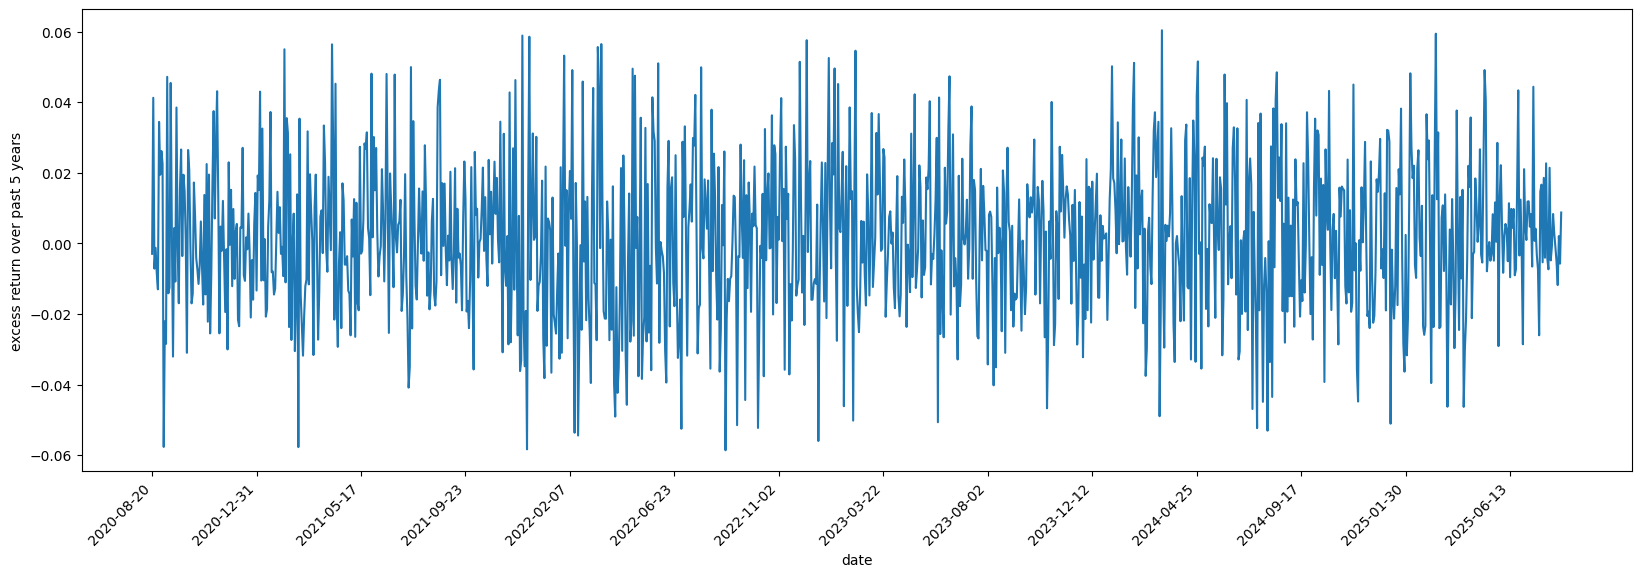

In [16]:
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(df["date"], df["excess_return"])
ax.set_xlabel('date')
ax.set_ylabel('excess return over past 5 years')
ticks = df["date"][::90]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45, ha='right')
plt.show()

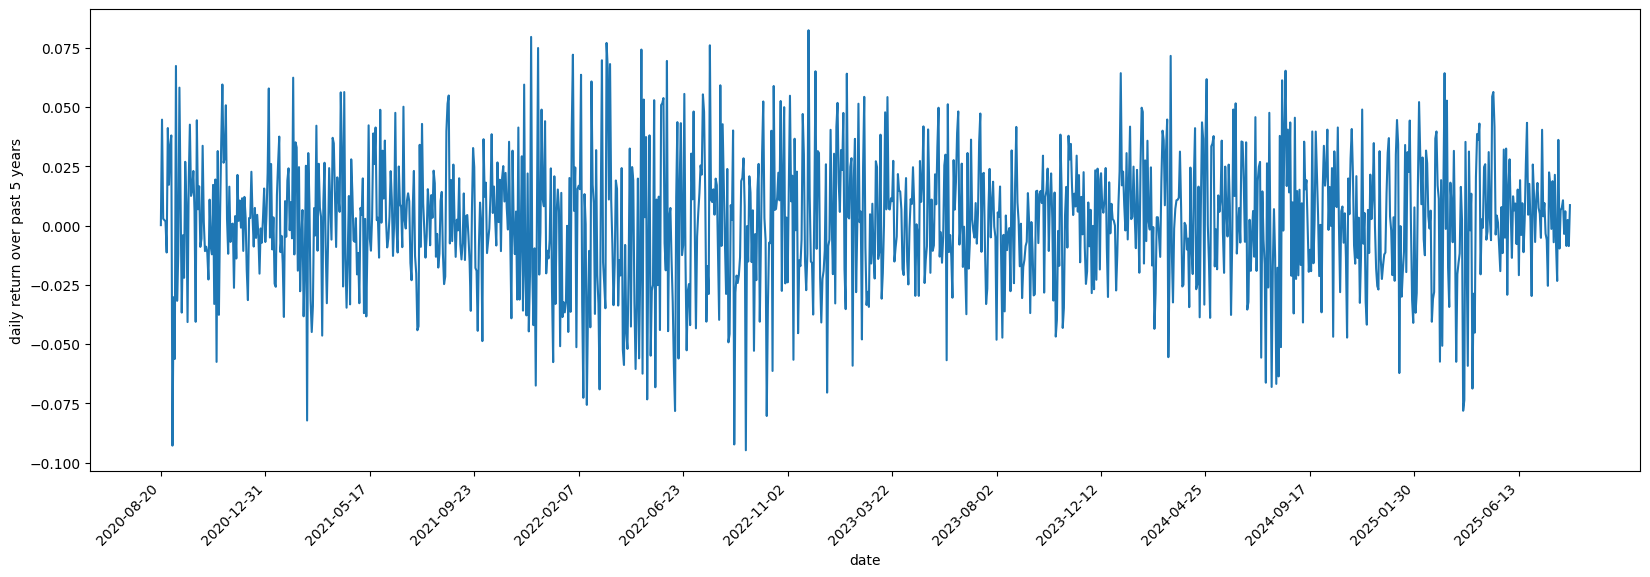

In [15]:
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(df["date"], df["daily_rtn"])
ax.set_xlabel('date')
ax.set_ylabel('daily return over past 5 years')
ticks = df["date"][::90]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45, ha='right')
plt.show()

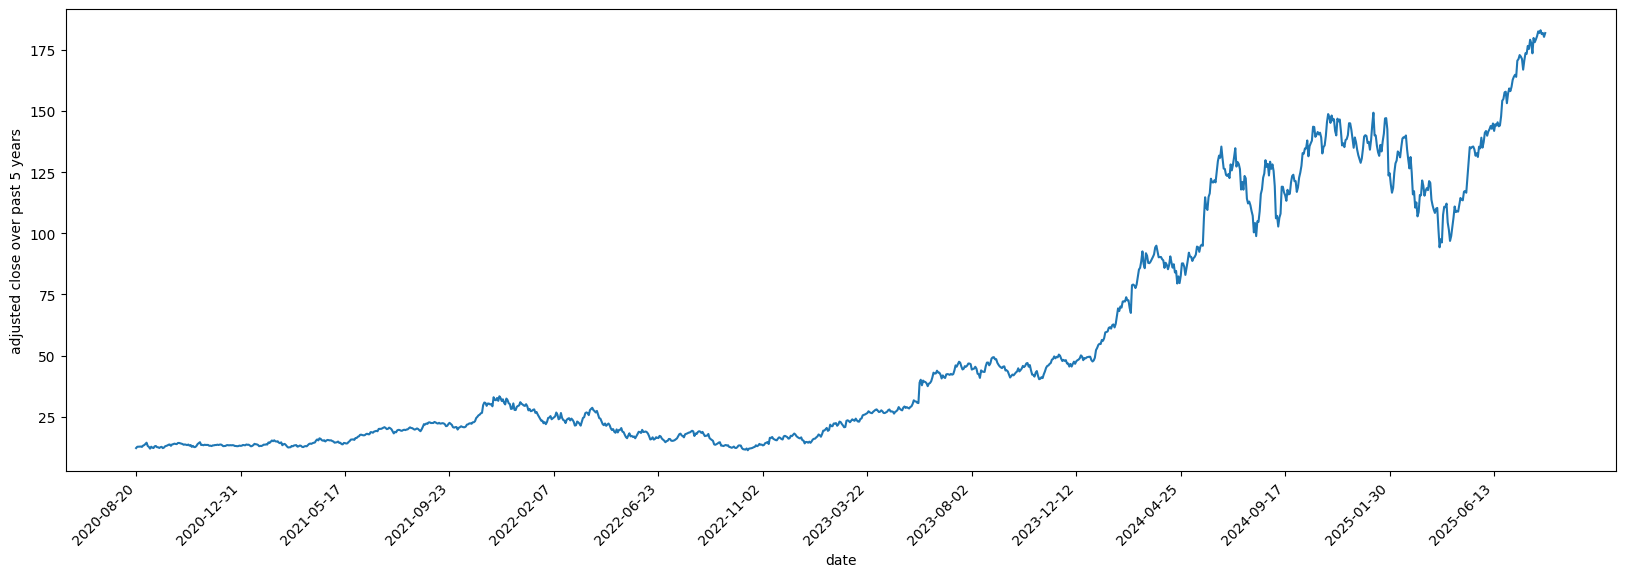

In [17]:
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(df["date"], df["adj close"])
ax.set_xlabel('date')
ax.set_ylabel('adjusted close over past 5 years')
ticks = df["date"][::90]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45, ha='right')
plt.show()

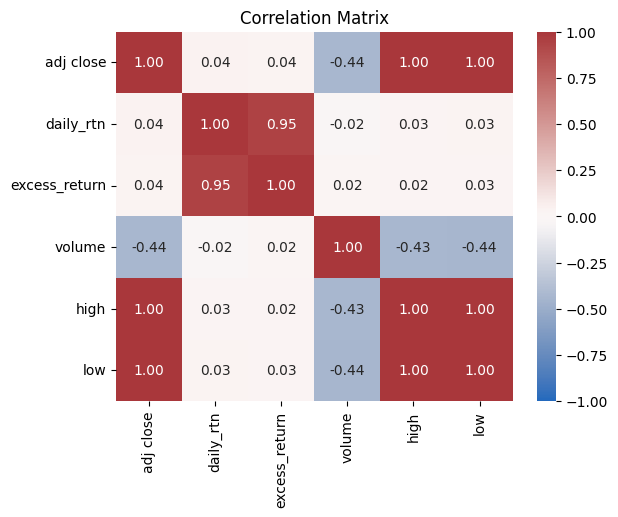

,adj close,daily_rtn,excess_return,volume,high,low
adj close,1.000000,0.039129,0.035009,-0.435266,0.999703,0.999790
daily_rtn,0.039129,1.000000,0.945206,-0.023666,0.027187,0.031484
excess_return,0.035009,0.945206,1.000000,0.016498,0.023830,0.027101
volume,-0.435266,-0.023666,0.016498,1.000000,-0.430203,-0.438795
high,0.999703,0.027187,0.023830,-0.430203,1.000000,0.999651
low,0.999790,0.031484,0.027101,-0.438795,0.999651,1.000000


In [18]:
corr = df[['adj close','daily_rtn','excess_return','volume',"high","low"]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
corr